# Stage B validation — AERONET-blind held-out (§8.2.2)

The headline gap-fill quality test.

**Blind protocol:** keep only `(slot, site)` pairs where AERONET observed but the Stage A daily product was *missing* at the AERONET cell.  Only gap-fill points count — observed pixels are excluded because they're not what's being graded.

AERONET aggregation: ±30 min around slot centre, identical to the Stage A protocol (§8.0).

In [1]:
from datetime import date
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import validate as vb
import config as cfg

START = cfg.TEST_START
END   = cfg.TEST_END
print(f'Held-out window: {START} → {END}')

Held-out window: 2025-01-01 → 2026-04-30


## Extract blind pairs for the RF candidate

One row per `(slot, site)` matched pair with AERONET, candidate value, provenance, uncertainty.

In [2]:
pairs_rf = vb.aeronet_pairs(START, END, candidate='rf', blind_only=True)
print(f'AERONET-blind RF pairs: {len(pairs_rf)}')
pairs_rf.head()

AERONET-blind RF pairs: 636


,slot_utc,local_day,slot_idx,site,region,season,aer_aod,aer_n_obs,sat_aod,is_observed,uncertainty,obs_was_valid
0,2025-01-02 06:30:00,2025-01-02,13,Bac_Lieu,south,dry,0.299391,1,0.337482,False,0.101457,False
1,2025-01-02 07:00:00,2025-01-02,14,Bac_Lieu,south,dry,0.297464,2,0.332858,False,0.112586,False
2,2025-01-02 07:30:00,2025-01-02,15,Bac_Lieu,south,dry,0.295537,1,0.335688,False,0.100448,False
3,2025-01-06 08:00:00,2025-01-06,16,Bac_Lieu,south,dry,0.352155,5,0.309495,False,0.067331,False
4,2025-01-06 08:30:00,2025-01-06,17,Bac_Lieu,south,dry,0.347513,8,0.305462,False,0.074340,False


## Metric panel — RF candidate

Per-site, per-(site, season), and pooled.  Metrics: `N`, `R`, `R²`, `RMSE`, `MAE`, `Bias`, `pct_EE` (within `0.05 + 0.15·|AERONET|` expected-error envelope).

In [3]:
vb.metric_panel(pairs_rf)

,N,R,R2,RMSE,MAE,Bias,pct_EE,label,site,season
0,422,0.297121,-0.118300,0.149413,0.124409,0.057054,34.834123,site=Bac_Lieu,Bac_Lieu,all
1,214,0.738882,0.182875,0.683133,0.350697,-0.239366,48.598131,site=NGHIA_DO,NGHIA_DO,all
2,229,0.638337,0.330293,0.134590,0.098243,-0.025797,55.895197,site=Bac_Lieu season=dry,Bac_Lieu,dry
3,193,0.565857,-7.214420,0.165285,0.155455,0.155359,9.844560,site=Bac_Lieu season=wet,Bac_Lieu,wet
4,122,0.728564,0.035443,0.877266,0.505046,-0.426357,40.163934,site=NGHIA_DO season=dry,NGHIA_DO,dry
5,92,0.342101,0.115480,0.254886,0.146016,0.008600,59.782609,site=NGHIA_DO season=wet,NGHIA_DO,wet
6,636,0.741529,0.341539,0.414532,0.200550,-0.042685,39.465409,ALL,ALL,all


## Scatter — RF vs AERONET

Visual sanity check; 1:1 line drawn for reference.

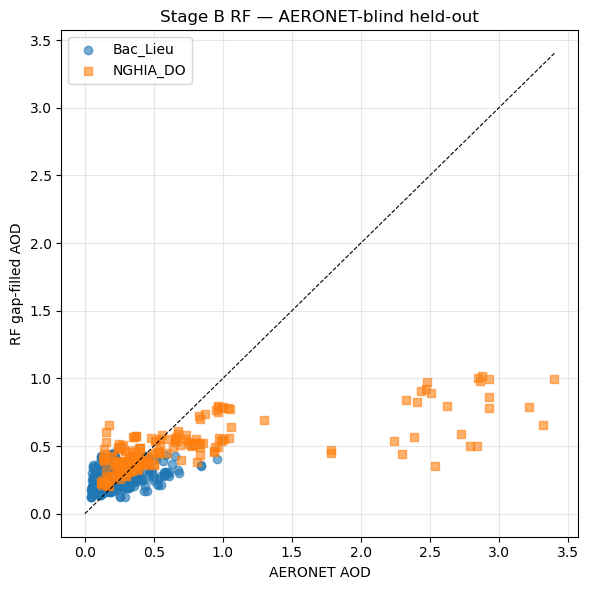

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
if pairs_rf.empty:
    ax.set_title('No matched pairs')
else:
    for site, marker in zip(pairs_rf['site'].unique(), ('o', 's', '^', 'D')):
        sub = pairs_rf[pairs_rf['site'] == site]
        ax.scatter(sub['aer_aod'], sub['sat_aod'], alpha=0.6, label=site, marker=marker)
    lim = max(pairs_rf[['aer_aod', 'sat_aod']].max().max(), 1.0)
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8)
    ax.set_xlabel('AERONET AOD'); ax.set_ylabel('RF gap-filled AOD')
    ax.set_title('Stage B RF — AERONET-blind held-out')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

# Krigging section

In [5]:
pairs_k = vb.aeronet_pairs(START, END, candidate='kriging', blind_only=True)
print(f'AERONET-blind Kriging pairs: {len(pairs_k)}')
pairs_k.head()

AERONET-blind Kriging pairs: 631


,slot_utc,local_day,slot_idx,site,region,season,aer_aod,aer_n_obs,sat_aod,is_observed,uncertainty,obs_was_valid
0,2025-01-02 06:30:00,2025-01-02,13,Bac_Lieu,south,dry,0.299391,1,0.323895,False,0.011621,False
1,2025-01-02 07:00:00,2025-01-02,14,Bac_Lieu,south,dry,0.297464,2,0.307287,False,0.011917,False
2,2025-01-02 07:30:00,2025-01-02,15,Bac_Lieu,south,dry,0.295537,1,0.288576,False,0.012288,False
3,2025-01-06 08:00:00,2025-01-06,16,Bac_Lieu,south,dry,0.352155,5,0.262818,False,0.005619,False
4,2025-01-06 08:30:00,2025-01-06,17,Bac_Lieu,south,dry,0.347513,8,0.303400,False,0.006731,False


In [6]:
vb.metric_panel(pairs_k)


,N,R,R2,RMSE,MAE,Bias,pct_EE,label,site,season
0,417,0.228752,-0.365477,0.165587,0.121421,0.052896,42.206235,site=Bac_Lieu,Bac_Lieu,all
1,214,0.789636,0.461393,0.554622,0.304347,-0.202175,42.523364,site=NGHIA_DO,NGHIA_DO,all
2,224,0.422615,0.171936,0.149785,0.111042,-0.009607,51.339286,site=Bac_Lieu season=dry,Bac_Lieu,dry
3,193,0.223077,-8.983724,0.182218,0.133466,0.125439,31.606218,site=Bac_Lieu season=wet,Bac_Lieu,wet
4,122,0.808130,0.402083,0.690697,0.404172,-0.323507,44.262295,site=NGHIA_DO season=dry,NGHIA_DO,dry
5,92,0.287752,-0.128552,0.287907,0.171970,-0.041278,40.217391,site=NGHIA_DO season=wet,NGHIA_DO,wet
6,631,0.784746,0.533485,0.349918,0.183459,-0.033610,42.313788,ALL,ALL,all


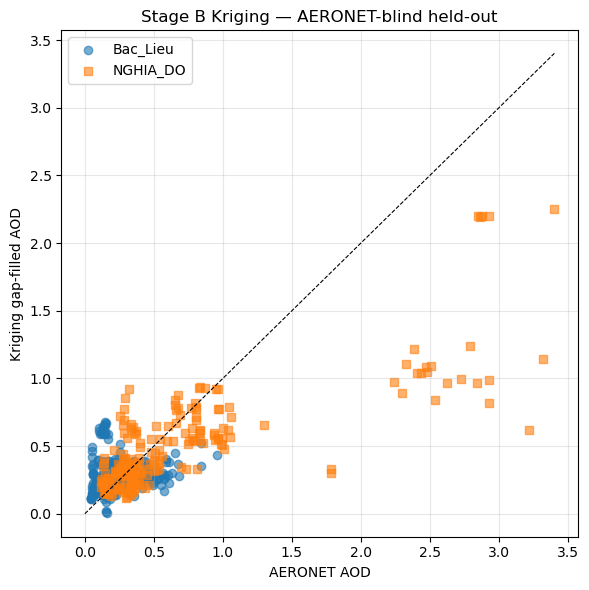

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
if pairs_k.empty:
    ax.set_title('No matched pairs')
else:
    for site, marker in zip(pairs_k['site'].unique(), ('o', 's', '^', 'D')):
        sub = pairs_k[pairs_k['site'] == site]
        ax.scatter(sub['aer_aod'], sub['sat_aod'], alpha=0.6, label=site, marker=marker)
    lim = max(pairs_k[['aer_aod', 'sat_aod']].max().max(), 1.0)
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8)
    ax.set_xlabel('AERONET AOD'); ax.set_ylabel('Kriging gap-filled AOD')
    ax.set_title('Stage B Kriging — AERONET-blind held-out')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()